In [1]:
import numpy as np
import matplotlib.pyplot as plt
from LinearExample import TestLinear



w = np.array([1., 1.])
b = 1.

M = 10

margin = 0.5

A, B = TestLinear(w, b, M//2, M//2, margin, seed=42)
print(f"dim(A): {A.shape}", f"dim(B): {B.shape}", sep='\n')
print(f"sample A:\n{A[:5]}", f"sample B:\n{B[:5]}", sep='\n')

dim(A): (5, 2)
dim(B): (5, 2)
sample A:
[[ 2.21218466  0.86748347]
 [ 2.32653944 -0.56506046]
 [ 1.1275847  -1.42047792]
 [-0.24261157  1.48983033]
 [ 0.19381071  1.25502122]]
sample B:
[[-1.69044037 -0.46239712]
 [ 0.42047792 -2.1275847 ]
 [-2.67296957 -0.76949868]
 [-1.21219595 -1.13600168]
 [-1.3617924  -1.31450386]]


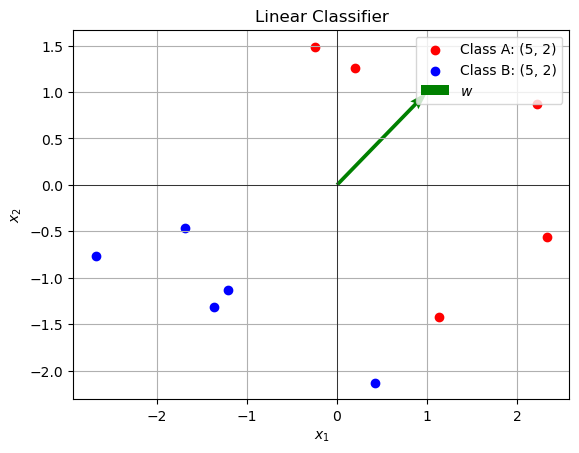

In [2]:
plt.scatter(A[:, 0], A[:, 1], c='r', label=f'Class A: {A.shape}')
plt.scatter(B[:, 0], B[:, 1], c='b', label=f'Class B: {B.shape}')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='g', label='$w$')
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.title('Linear Classifier')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid()
plt.show()

In [3]:
X = np.vstack((A, B))
G = X @ X.T
print(f"dim(X): {X.shape}", f"dim(G): {G.shape}", sep=' | ')
print(X)

dim(X): (10, 2) | dim(G): (10, 10)
[[ 2.21218466  0.86748347]
 [ 2.32653944 -0.56506046]
 [ 1.1275847  -1.42047792]
 [-0.24261157  1.48983033]
 [ 0.19381071  1.25502122]
 [-1.69044037 -0.46239712]
 [ 0.42047792 -2.1275847 ]
 [-2.67296957 -0.76949868]
 [-1.21219595 -1.13600168]
 [-1.3617924  -1.31450386]]


In [4]:
y = np.hstack((np.ones(M//2), -np.ones(M//2)))
Y = np.diag(y)
H = Y.T @ G @ Y
print(f"dim(y): {y.shape}", f"dim(Y.T): {(Y.T).shape}", f"dim(G): {G.shape}", f"dim(H): {H.shape}", sep=' | ')


dim(y): (10,) | dim(Y.T): (10, 10) | dim(G): (10, 10) | dim(H): (10, 10)


In [5]:


def f(alpha):
    M = np.size(alpha)
    print(M)
    H = Y.T @ G @ Y
    print(H.shape)
    return 1/2* alpha.T @ H @ alpha - np.ones(M).T @ alpha

def grad_f(alpha):
    M = alpha.shape
    print(M)
    H = Y.T @ G @ Y    
    return 1/2 * alpha.T @ H @ alpha - np.ones(M)

alpha = np.ones(M)

print(f'dim(alpha): {alpha.shape}, dim(f(alpha)): {f(alpha).shape}')


10
(10, 10)
dim(alpha): (10,), dim(f(alpha)): ()


In [6]:
C = 1

import numpy as np

class SVM:
    """
    A simple illustration of projected gradient for the SVM dual problem:
    
        min_{alpha in R^M}  (1/2) alpha^T (Y G Y) alpha - 1^T alpha
        subject to          sum_i y_i alpha_i = 0,   0 <= alpha_i <= C.
        
    with:
      - G = X @ X.T,
      - Y is (M x M) diagonal with +/-1,
      - alpha in R^M,
      - C > 0 is the penalty parameter.
    """

    def __init__(self, C, Y_diag, X, eps=1e-5):
        """
        Parameters
        ----------
        C : float
            The box constraint upper bound on alpha_i.
        Y_diag : np.ndarray, shape (M,M)
            Diagonal matrix (M x M) with +/-1 along diag. (Or you could store just a vector of signs.)
        X : np.ndarray, shape (M, d)
            Data, used to form Gram matrix G = X X^T
        eps : float
            Tolerance for convergence in bisection, etc.
        """
        self.C = C
        self.Y = Y_diag           # shape (M,M), diag is +1/-1
        self.G = X @ X.T          # Gram matrix
        self.G_tl = Y_diag @ self.G @ Y_diag
        self.eps = eps
        self.M = X.shape[0]

        # parameters for bisection and step-size bounding
        self.delta = 1.0
        self.lmd_bracket = (-1.0, 1.0)   # initial bracket for lambda
        self.t_min, self.t_max = 1e-4, 1e5  # clamp for step sizes

    # -----------------------------------------------------------
    # The function alpha(\lambda, beta) = clip( beta + lambda*y, 0, C )
    # (where y_i = +/-1 are the diagonal entries of Y).
    # -----------------------------------------------------------
    def alpha_lambda(self, lmbd, beta):
        """
        For a given lambda and "unconstrained step" beta,
        compute alpha_i = clamp( beta_i + lmbd*y_i, 0, C ).
        """
        y_vec = np.diag(self.Y)  # shape (M,)
        return np.minimum( self.C, np.maximum( 0.0, beta + lmbd*y_vec ) )

    # -----------------------------------------------------------
    # Bisection method to find lambda so that sum_i y_i alpha_i = 0
    # -----------------------------------------------------------
    def find_lmbd(self, beta):
        eps = self.eps
        lmd_l, lmd_u = self.lmd_bracket
        y_vec = np.diag(self.Y)

        def sum_y_alpha(lmbd):
            a = self.alpha_lambda(lmbd, beta)
            return (y_vec * a).sum()   # scalar

        # Ensure we can bracket the zero of sum_y_alpha(lambda):
        # Expand downward for lmd_l
        while sum_y_alpha(lmd_l) > 0:
            lmd_l -= self.delta
            lmd_u = lmd_l

        # Expand upward for lmd_u
        while sum_y_alpha(lmd_u) < 0:
            lmd_u += self.delta
            lmd_l = lmd_u
        
        while True:
            lmd_h = 0.5*(lmd_l + lmd_u)
            val = sum_y_alpha(lmd_h)
            if abs(val) < eps:
                return lmd_h
            if val > 0:
                lmd_l = lmd_h
            else:
                lmd_u = lmd_h

    # -----------------------------------------------------------
    # The dual objective function: f(alpha) = (1/2) alpha^T G_tl alpha - 1^T alpha
    # -----------------------------------------------------------
    def f(self, alpha):
        return 0.5 * alpha.T @ self.G_tl @ alpha - np.sum(alpha)

    # -----------------------------------------------------------
    # Gradient of the objective: grad f(alpha) = G_tl alpha - 1
    # -----------------------------------------------------------
    def grad_f(self, alpha):
        return (self.G_tl @ alpha) - np.ones(self.M)

    # -----------------------------------------------------------
    # Barzilai-Borwein formula
    # s_k = alpha^{(k+1)} - alpha^{(k)}
    # z_k = grad_f(alpha^{(k+1)}) - grad_f(alpha^{(k)})
    # tauBB = (s_k^T s_k) / (s_k^T z_k)   or other variant
    # -----------------------------------------------------------
    @staticmethod
    def barzilai_borwein_step(s_k, z_k):
        denom = s_k.dot(z_k)
        if abs(denom) < 1e-15:
            return 1e-3
        return s_k.dot(s_k) / denom

    # -----------------------------------------------------------
    # The main solve / fit method: Projected gradient iteration
    # -----------------------------------------------------------
    def fit(self, max_iter=1000):
        # 1) Initialization
        alpha_k = np.zeros(self.M)  # a feasible initial guess: sum_i y_i*0=0
        # Evaluate f and grad
        f_k = self.f(alpha_k)
        g_k = self.grad_f(alpha_k)

        # For the first step, let's pick a small constant step
        tau_init = 1e-2
        beta_0 = alpha_k - tau_init*g_k   # unconstrained step
        # project onto feasible set
        lam_0 = self.find_lmbd(beta_0)
        alpha_next = self.alpha_lambda(lam_0, beta_0)
        f_next = self.f(alpha_next)
        g_next = self.grad_f(alpha_next)

        # Start iterating
        for it in range(max_iter):
            # s_k and z_k for BB
            s_k = alpha_next - alpha_k
            z_k = g_next - g_k

            # Barzilai-Borwein
            tau_BB = self.barzilai_borwein_step(s_k, z_k)
            # clamp to [t_min, t_max]
            tau_k = max( min(tau_BB, self.t_max), self.t_min )

            # unconstrained step
            beta = alpha_next - tau_k * g_next
            # project
            lam_star = self.find_lmbd(beta)
            alpha_new = self.alpha_lambda(lam_star, beta)

            # optional stopping
            if np.linalg.norm(alpha_new - alpha_next) < self.eps:
                alpha_next = alpha_new
                break

            # shift old -> next
            alpha_k, f_k, g_k = alpha_next, f_next, g_next
            alpha_next = alpha_new
            f_next = self.f(alpha_next)
            g_next = self.grad_f(alpha_next)
    

        # store final solution
        self.alpha_opt = alpha_next
        return alpha_next



# Example usage
M = 1_000
C = 1.0

A, B = TestLinear(w, b, M//2, M//2, margin, seed=42)
X = np.vstack((A, B))
Y = np.hstack((np.ones(M//2), -np.ones(M//2)))
Y_diag = np.diag(Y)
print(f"dim(X): {X.shape}", f"dim(Y_diag): {Y_diag.shape}", sep=' | ')
print(f"dim(Y): {Y.shape}", f"dim(G): {(X @ X.T).shape}", sep=' | ')
svm = SVM(C, Y_diag, X)

svm.fit(max_iter=100)

dim(X): (1000, 2) | dim(Y_diag): (1000, 1000)


dim(Y): (1000,) | dim(G): (1000, 1000)


KeyboardInterrupt: 

dim(A): (5, 2)
dim(B): (5, 2)
sample A:
[[ 2.21218466  0.86748347]
 [ 2.32653944 -0.56506046]
 [ 1.1275847  -1.42047792]
 [-0.24261157  1.48983033]
 [ 0.19381071  1.25502122]]
sample B:
[[-1.69044037 -0.46239712]
 [ 0.42047792 -2.1275847 ]
 [-2.67296957 -0.76949868]
 [-1.21219595 -1.13600168]
 [-1.3617924  -1.31450386]]


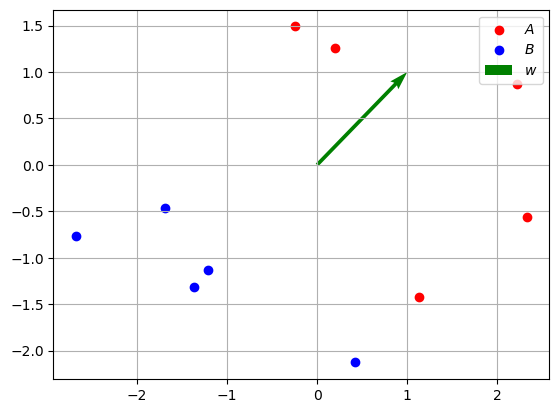

dim(X): (10, 2) | dim(G): (10, 10)
dim(y): (10,) | dim(Y.T): (10, 10) | dim(G): (10, 10) | dim(H): (10, 10)


In [ ]:
class SVM:
    def __init__(self, C, Y, X, eps=1e-5):
        self.C = C
        self.Y = Y
        self.G = X @ X.T
        self.G_tl = Y @ self.G @ Y
        self.eps = eps
        self.M = X.shape[0]

        self.delta = 1
        self.lmd = (0.0, 10e-5)
        self.t_min, self.t_max = 10e-3, 10e5

    def _alpha(self, lmbd, beta):
        return np.minimum(self.C, np.maximum(0, beta + lmbd * self.Y.diagonal()))

    def find_lmbd(self, beta):
        eps = self.eps
        lmd_l, lmd_u = self.lmd

        while np.any(self.Y.T @ self._alpha(lmd_l, beta) > 0):
            lmd_l = lmd_l - self.delta
            lmd_u = lmd_l
        while np.any(self.Y.T @ self._alpha(lmd_u, beta) < 0):
            lmd_u = lmd_u + self.delta
            lmd_l = lmd_u

        while True:
            lmd_h = (lmd_l + lmd_u) / 2
            f = self.Y @ self._alpha(lmd_h, beta)

            if np.all(np.abs(f) < eps):
                return lmd_h
            elif np.any(f > 0):
                lmd_l = lmd_h
            else:
                lmd_u = lmd_h

    def f(self, alpha):
        return 1 / 2 * alpha.T @ self.G_tl @ alpha - np.ones(self.M) @ alpha

    def grad_f(self, alpha):
        return self.G_tl @ alpha - np.ones(self.M)

    def fit(self, max_iter=1000):
        # Initialize
        ak = np.zeros(self.M)               # alpha^0
        tk = 1e-2                           # initial step size
        fk = self.f(ak)                     # f(ak)
        gk = self.grad_f(ak)                # grad(ak)
        
        bk = ak - tk*gk
        
        lk = self.find_lmbd(bk)
        a_k = self._alpha(lk, bk)

        # we can re-eval the function / gradient at a_k
        f_k = self.f(a_k)
        g_k = self.grad_f(a_k)
        
        for iter in range(max_iter):
            sk = a_k - ak
            zk = g_k - gk
            
            # check if s_k @ z_k <= 0
            if (sk @ zk) <= 0:
                t_k = self.t_max
            else:
                tBB_k = (sk @ sk)/(sk @ zk)
                t_k = max(min(tBB_k, self.t_max), self.t_min)
            
            # unconstrained step
            b_new = a_k - t_k*g_k
            lam_star = self.find_lmbd(b_new)
            a_new = self._alpha(lam_star, b_new)
            
            # update
            ak = a_k
            a_k = a_new
            
            fk = f_k
            f_k = self.f(a_k)
            
            gk = g_k
            g_k = self.grad_f(a_k)
            
            if np.linalg.norm(a_k - ak) < self.eps:
                break
        
        self.a_opt = a_k
        return a_k


M = 10
margin = 0.5
w = np.array([1., 1.])
b = 1.

A, B = TestLinear(w, b, M//2, M//2, margin, seed=42)
print(f"dim(A): {A.shape}", f"dim(B): {B.shape}", sep='\n')
print(f"sample A:\n{A[:5]}", f"sample B:\n{B[:5]}", sep='\n')
plt.scatter(A[:, 0], A[:, 1], c='r', label='$A$')
plt.scatter(B[:, 0], B[:, 1], c='b', label='$B$')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='g', label='$w$')
plt.legend()
plt.grid()
plt.show()

X = np.vstack((A, B))
G = X @ X.T
print(f"dim(X): {X.shape}", f"dim(G): {G.shape}", sep=' | ')

y = np.hstack((np.ones(M//2), -np.ones(M//2)))
Y = np.diag(y)
H = Y.T @ G @ Y
print(f"dim(y): {y.shape}", f"dim(Y.T): {(Y.T).shape}", f"dim(G): {G.shape}", f"dim(H): {H.shape}", sep=' | ')



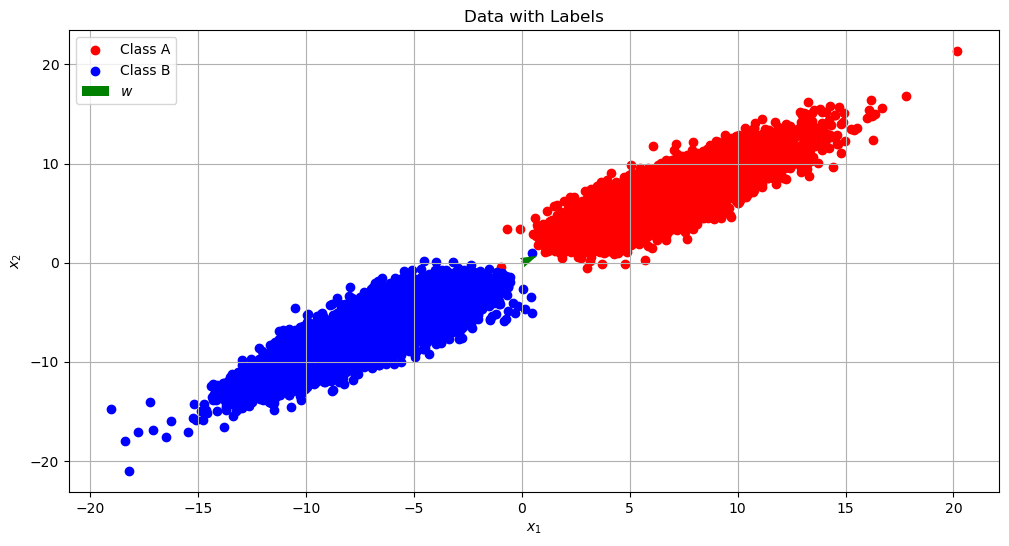

Learned w (test) = [0.54165192 0.41993306]
Learned b (test) = -0.049999999999954164
Training Time: 35.82681012 seconds
Training Accuracy (test) = 99.99%


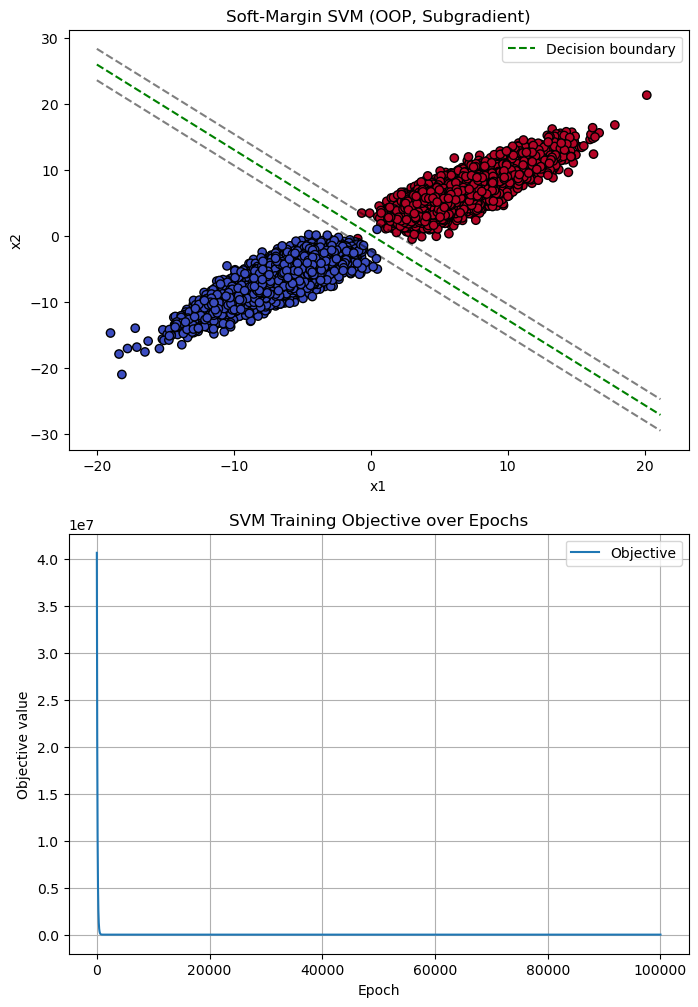

In [ ]:
import time
class SVM:
    def __init__(self, C=1.0, max_epochs=1000, lr=0.001):
        """
        Parameters
        ----------
        C: Penalty parameter for misclassified (slack) points.
        max_epochs: Number of passes (epochs) over the training set.
        lr : Fixed learning rate for subgradient steps.
        """
        self.C = C
        self.max_epochs = max_epochs
        self.lr = lr
        
        self.w_ = None  # shape (d,)
        self.b_ = None  # scalar
        
        self.history_ = []

    def fit(self, X, y):
        """
        Fit a linear soft-margin SVM using subgradient descent.

        Parameters
        ----------
        X : shape (d, M) Feature matrix with M samples in d dimensions
        y : shape (M,) Labels in {+1, -1} for each sample

        Returns
        -------
        self : Fitted SVM model
        """
        d, M = X.shape

        # Initialize model parameters
        self.w_ = np.zeros(d)
        self.b_ = 0.0
        self.history_ = []

        for epoch in range(self.max_epochs):
            grad_w = self.w_.copy()
            grad_b = 0.0

            margin = 1 - y * (self.w_ @ X + self.b_)
            active = (margin > 0)

            if np.any(active):
                grad_w -= self.C * np.sum((y[active] * X[:, active]), axis=1)
                grad_b -= self.C * np.sum(y[active])

            self.w_ = self.w_ - self.lr * grad_w
            self.b_ = self.b_ - self.lr * grad_b

            hinge_vals = np.maximum(0.0, margin)
            obj = 0.5 * np.sum(self.w_**2) + self.C * np.sum(hinge_vals)
            self.history_.append(obj)

        return self

    def distance(self, X):
        return self.w_ @ X + self.b_

    def predict(self, X):
        dist = self.distance(X)
        return np.sign(dist)
    
    def plot(self, X, y):
        fig, ax = plt.subplots(2, 1, figsize=(8, 12))
        ax[0].scatter(X[0,:], X[1,:], c=y, cmap='coolwarm', edgecolors='k')
        ax[0].set_title("Data with Labels")
        ax[0].set_xlabel("$x_1$")
        ax[0].set_ylabel("$x_2$")
        ax[0].grid()
        # Decision boundary
        x_min, x_max = X[0,:].min() - 1, X[0,:].max() + 1
        xx = np.linspace(x_min, x_max, 100)
        if abs(self.w_[1]) > 1e-9:
            yy = -(self.b_ + self.w_[0]*xx)/self.w_[1]
            ax[0].plot(xx, yy, 'g--', label="Decision boundary")
            # Margins: w^T x + b = ±1
            yy_plus = -(self.b_ + self.w_[0]*xx - 1)/self.w_[1]
            yy_minus = -(self.b_ + self.w_[0]*xx + 1)/self.w_[1]
            ax[0].plot(xx, yy_plus, 'k--', alpha=0.5)
            ax[0].plot(xx, yy_minus, 'k--', alpha=0.5)
        ax[0].set_title("Soft-Margin SVM (OOP, Subgradient)")
        ax[0].set_xlabel("x1")
        ax[0].set_ylabel("x2")
        ax[0].legend()
        ax[0].grid()
        
        # Plot objective history
        ax[1].plot(self.history_, label="Objective")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Objective value")
        ax[1].set_title("SVM Training Objective over Epochs")
        ax[1].legend()
        ax[1].grid()
        plt.show()
    
    def test_time(self):
        start = time.time()
        self.predict(X)
        end = time.time()
        print(f"Prediction Time: {end - start:.8f} seconds")

nA = nB = 10000

w_gt = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) 
b_gt = 0.
margin_gt= -1.

listA, listB = TestLinear(w_gt, b_gt, nA, nB, margin_gt, seed=42, shape=10, noise=0.1)

A = np.array(listA).T  # shape (2, nA)
B = np.array(listB).T  # shape (2, nB)

X = np.concatenate([A, B], axis=1)
yA = np.ones(nA)
yB = -np.ones(nB)
y = np.concatenate([yA, yB], axis=0)

fig, ax = plt.subplots(1,1, figsize=(12, 6))
ax.scatter(A[0,:], A[1,:], c='r', label='Class A')
ax.scatter(B[0,:], B[1,:], c='b', label='Class B')
ax.quiver(0, 0, w_gt[0], w_gt[1], angles='xy', scale_units='xy', scale=1, color='g', label='$w$')
ax.set_title("Data with Labels")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
ax.grid()
plt.show()
# Test the SVM class
svm_test = SVM(C=10.0, max_epochs=100000, lr=0.005)
t0 = time.time()
svm_test.fit(X, y)
print("Learned w (test) =", svm_test.w_)
print("Learned b (test) =", svm_test.b_)
preds_test = svm_test.predict(X)
t1 = time.time()
print(f"Training Time: {t1 - t0:.8f} seconds")
accuracy_test = np.mean(preds_test == y)
print("Training Accuracy (test) = {:.2f}%".format(100*accuracy_test))
svm_test.plot(X, y)